# Optional Lab: Fourier-Based Defect Detection

This optional notebook uses the Fourier transform for a defect-detection question: **does this image look damaged or not damaged?**

Fourier features can be useful for defects because damage often changes edges, texture, repeated patterns, or small high-frequency details. We will use two ideas:

- a supervised classifier trained on frequency summaries
- a clean-reference anomaly score that asks how far an image is from normal frequency behavior

At the end, we also make a simple patch-level Fourier heatmap to point toward suspicious regions.

## 1. Imports and workshop helpers

In [1]:
# Standard library tools for file paths, timing, and warnings.
from pathlib import Path
import math
import sys
import time
import warnings

# Data-science libraries for arrays, tables, plots, and images.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

# Classical machine-learning models and evaluation tools.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Find the notebook folder so imports and dataset paths work from either the
# repository root or the 0_Class_Notebooks folder.
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "0_Class_Notebooks":
    candidate = NOTEBOOK_DIR / "0_Class_Notebooks"
    if candidate.exists():
        NOTEBOOK_DIR = candidate

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from workshop_image_utils import (
    load_image_records,
    load_images_as_arrays,
    record_timing,
    safe_stratify_labels,
    timing_frame,
    validate_target_mode,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

step_timings = []

## 2. Configuration

In [2]:
SOURCE_DATASET_ROOT = (NOTEBOOK_DIR.parent / "Device_Images_Nelson").resolve()
AUGMENTED_DEVICE_ROOT = (NOTEBOOK_DIR.parent / "Augmented_Device_Images").resolve()
AUGMENTED_LOCALIZATION_ROOT = (NOTEBOOK_DIR.parent / "Augmented_Defect_Localization_Images").resolve()
DATASET_ROOT = AUGMENTED_DEVICE_ROOT if (AUGMENTED_DEVICE_ROOT / "metadata.csv").exists() else AUGMENTED_LOCALIZATION_ROOT
METADATA_PATH = DATASET_ROOT / "metadata.csv"

# Student change points.
IMAGE_SIZE = 96
TEST_SIZE = 0.30
RANDOM_STATE = 42
INCLUDED_DEVICE_TYPES = None  # Try ["device 3"] or ["device1", "device 2"] to narrow the task.
MAX_IMAGES_PER_CLASS = None  # Try 40 for a faster, smaller experiment.

# Fourier feature choices.
FOURIER_BINS = 24
LOW_FREQUENCY_CUTOFF = 0.00
HIGH_FREQUENCY_CUTOFF = 1.00
INCLUDE_BRIGHTNESS_FEATURES = True

# Clean-reference anomaly detector choices.
NORMAL_LABEL = "Not-Damaged"
DEFECT_LABEL = "Damaged"
ANOMALY_THRESHOLD_PERCENTILE = 95

# Patch heatmap choices.
PATCH_SIZE = 16
PATCH_HIGH_FREQUENCY_START = 0.45
HEATMAP_ZSCORE_CLIP = 5.0

print(f"Source dataset root: {SOURCE_DATASET_ROOT}")
print(f"Augmented device root: {AUGMENTED_DEVICE_ROOT}")
print(f"Augmented localization root: {AUGMENTED_LOCALIZATION_ROOT}")
print(f"Active dataset root: {DATASET_ROOT}")
print(f"Metadata file exists: {METADATA_PATH.exists()}")
print(f"Image size: {IMAGE_SIZE}")
print(f"Fourier bins: {FOURIER_BINS}")

Source dataset root: C:\Users\l-a-c\1.repositories\Summer_Workshop_Data_Driven_Decision_Making\Device_Images_Nelson
Augmented device root: C:\Users\l-a-c\1.repositories\Summer_Workshop_Data_Driven_Decision_Making\Augmented_Device_Images
Augmented localization root: C:\Users\l-a-c\1.repositories\Summer_Workshop_Data_Driven_Decision_Making\Augmented_Defect_Localization_Images
Active dataset root: C:\Users\l-a-c\1.repositories\Summer_Workshop_Data_Driven_Decision_Making\Augmented_Device_Images
Metadata file exists: True
Image size: 96
Fourier bins: 24


## 3. Load labeled defect data

In [3]:
started = time.perf_counter()
all_records = load_image_records(DATASET_ROOT, metadata_path=METADATA_PATH if METADATA_PATH.exists() else None)
record_timing(step_timings, "dataset_scan", started)

records = all_records[all_records["damage_status"].notna()].reset_index(drop=True)
records = records[records["damage_status"].isin([NORMAL_LABEL, DEFECT_LABEL])].reset_index(drop=True)

if INCLUDED_DEVICE_TYPES is not None:
    records = records[records["device_type"].isin(INCLUDED_DEVICE_TYPES)].reset_index(drop=True)

if MAX_IMAGES_PER_CLASS is not None:
    records = (
        records.groupby("damage_status", group_keys=False)
        .apply(lambda frame: frame.sample(min(len(frame), MAX_IMAGES_PER_CLASS), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )

is_valid_target, target_message = validate_target_mode(records, "damage_status")
print(target_message)
if not is_valid_target:
    raise ValueError(target_message)

device_summary = (
    records.groupby(["device_type", "damage_status"], dropna=False)
    .size()
    .rename("count")
    .reset_index()
)
device_pivot = device_summary.pivot_table(
    index="device_type",
    columns="damage_status",
    values="count",
    fill_value=0,
)

print(f"Records used: {len(records)}")
display(device_summary)
if not all(label in device_pivot.columns for label in [NORMAL_LABEL, DEFECT_LABEL]):
    display(Markdown("**Caution:** one of the damage classes is missing from the device summary."))
else:
    paired_devices = device_pivot[(device_pivot[NORMAL_LABEL] > 0) & (device_pivot[DEFECT_LABEL] > 0)]
    if paired_devices.empty:
        display(Markdown(
            "**Caution:** no device type has both damaged and not-damaged examples. "
            "A model may learn device differences instead of defect evidence."
        ))
display(records.head())

Target `damage_status` is ready with classes: ['Damaged', 'Not-Damaged']
Records used: 80


,device_type,damage_status,count
0,device 2,Damaged,25
1,device 2,Not-Damaged,30
2,device1,Damaged,15
3,device1,Not-Damaged,10


,filepath,relative_path,device_type,damage_status,top_level_folder,has_damage_label,has_device_type_label,device_type_label_source,is_defect_folder,is_standard_device_image,is_defect_challenge
0,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,Defect/1_Defect(1).png,device1,Damaged,Defect,True,True,filename-prefix,True,False,True
1,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,Defect/1_Defect(1)_aug_001.jpg,device1,Damaged,Defect,True,True,filename-prefix,True,False,True
2,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,Defect/1_Defect(1)_aug_018.jpg,device1,Damaged,Defect,True,True,filename-prefix,True,False,True
3,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,Defect/1_Defect(2).png,device1,Damaged,Defect,True,True,filename-prefix,True,False,True
4,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,Defect/1_Defect(2)_aug_002.jpg,device1,Damaged,Defect,True,True,filename-prefix,True,False,True


## 4. Class balance

,count
damage_status,
Damaged,40
Not-Damaged,40


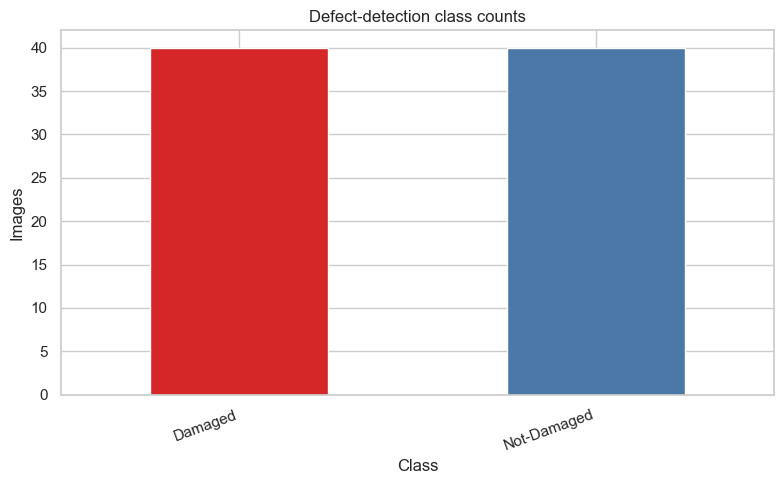

In [4]:
class_counts = records["damage_status"].value_counts(dropna=True).sort_index()
display(class_counts.rename("count").to_frame())

ax = class_counts.plot(kind="bar", color=["#d62728", "#4c78a8"], title="Defect-detection class counts")
ax.set_xlabel("Class")
ax.set_ylabel("Images")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 5. Load grayscale images

In [5]:
started = time.perf_counter()
image_arrays, filtered_records = load_images_as_arrays(
    records,
    image_size=IMAGE_SIZE,
    color_mode="grayscale",
    progress_title="Load defect images",
)
record_timing(step_timings, "load_grayscale_images", started)

labels = filtered_records["damage_status"].astype(str).to_numpy()
images_scaled = image_arrays.astype(float) / 255.0

print("Image array shape:", image_arrays.shape)
print("Labels shape:", labels.shape)

Image array shape: (80, 96, 96)
Labels shape: (80,)


## 6. Fourier view of clean and damaged examples

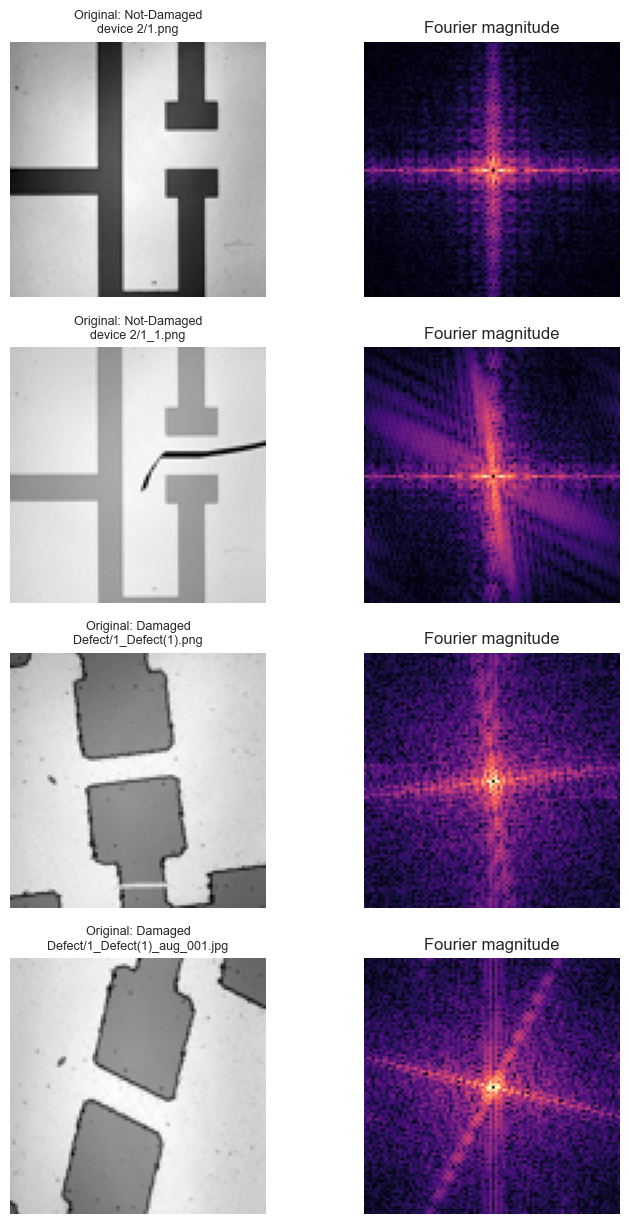

In [6]:
def fourier_magnitude_image(image_2d):
    centered = image_2d.astype(float) - image_2d.mean()
    spectrum = np.fft.fftshift(np.fft.fft2(centered))
    return np.log1p(np.abs(spectrum))


example_indices = []
for label_name in [NORMAL_LABEL, DEFECT_LABEL]:
    matches = np.where(labels == label_name)[0]
    example_indices.extend(matches[:2].tolist())

fig, axes = plt.subplots(len(example_indices), 2, figsize=(8, 3.1 * len(example_indices)))
axes = np.atleast_2d(axes)

for row_index, image_index in enumerate(example_indices):
    image = images_scaled[image_index]
    label = labels[image_index]
    rel_path = filtered_records.iloc[image_index]["relative_path"]

    axes[row_index, 0].imshow(image, cmap="gray")
    axes[row_index, 0].set_title(f"Original: {label}\n{rel_path}", fontsize=9)
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(fourier_magnitude_image(image), cmap="magma")
    axes[row_index, 1].set_title("Fourier magnitude")
    axes[row_index, 1].axis("off")

plt.tight_layout()
plt.show()

## 7. Extract global Fourier features

In [7]:
def make_frequency_masks(image_size, n_bins, low_cutoff=0.0, high_cutoff=1.0):
    y, x = np.indices((image_size, image_size))
    center = (image_size - 1) / 2
    radius = np.sqrt((x - center) ** 2 + (y - center) ** 2)
    radius = radius / radius.max()

    edges = np.linspace(low_cutoff, high_cutoff, n_bins + 1)
    masks = []
    names = []
    for start, stop in zip(edges[:-1], edges[1:]):
        mask = (radius >= start) & (radius < stop)
        if mask.any():
            masks.append(mask)
            names.append(f"freq_{start:.2f}_{stop:.2f}")
    return masks, names


def extract_fourier_features(images, n_bins=24, low_cutoff=0.0, high_cutoff=1.0, include_brightness=True):
    masks, names = make_frequency_masks(images.shape[1], n_bins, low_cutoff, high_cutoff)
    rows = []

    for image in images:
        centered = image - image.mean()
        spectrum = np.fft.fftshift(np.fft.fft2(centered))
        power = np.abs(spectrum) ** 2
        total_power = power.sum() + 1e-12

        row = []
        for mask in masks:
            band_energy = power[mask].sum() / total_power
            row.append(np.log1p(band_energy * 1_000_000))

        if include_brightness:
            row.extend([image.mean(), image.std()])

        rows.append(row)

    feature_names = names.copy()
    if include_brightness:
        feature_names.extend(["mean_brightness", "contrast"])

    return np.array(rows), feature_names


started = time.perf_counter()
X_fourier, fourier_feature_names = extract_fourier_features(
    images_scaled,
    n_bins=FOURIER_BINS,
    low_cutoff=LOW_FREQUENCY_CUTOFF,
    high_cutoff=HIGH_FREQUENCY_CUTOFF,
    include_brightness=INCLUDE_BRIGHTNESS_FEATURES,
)
record_timing(step_timings, "fourier_feature_extraction", started)

print("Fourier feature matrix shape:", X_fourier.shape)
display(pd.DataFrame(X_fourier, columns=fourier_feature_names).head())

Fourier feature matrix shape: (80, 26)


,freq_0.00_0.04,freq_0.04_0.08,freq_0.08_0.12,freq_0.12_0.17,freq_0.17_0.21,freq_0.21_0.25,freq_0.25_0.29,freq_0.29_0.33,freq_0.33_0.38,freq_0.38_0.42,...,freq_0.67_0.71,freq_0.71_0.75,freq_0.75_0.79,freq_0.79_0.83,freq_0.83_0.88,freq_0.88_0.92,freq_0.92_0.96,freq_0.96_1.00,mean_brightness,contrast
0,13.127728,12.193263,11.250893,10.824655,10.246177,10.182548,10.013162,9.670009,9.679187,9.513764,...,8.308026,7.474449,6.322052,5.828169,5.331953,4.963995,4.388597,3.241109,0.624800,0.111008
1,13.107041,12.248434,11.267099,10.636935,10.468332,10.253068,9.859011,9.933140,9.620643,9.362675,...,8.158057,7.486039,6.944869,6.134425,5.289752,4.682362,4.018707,3.075965,0.627906,0.103592
2,13.061588,12.311228,11.104161,10.917122,10.412856,10.309909,10.126814,10.003261,9.587390,9.641503,...,7.980943,7.583201,6.739076,6.166946,5.377071,4.786953,4.170186,2.535842,0.692292,0.132136
3,13.065888,12.211386,11.305005,11.035995,10.465370,10.300825,10.032716,9.652802,9.693346,9.487787,...,8.309442,7.483560,6.307172,5.828572,5.363088,4.976939,4.434941,3.328483,0.628166,0.108664
4,13.166204,12.140870,11.007964,10.965970,10.217366,10.390078,9.839990,9.944668,9.554872,9.588231,...,7.954154,7.508263,6.624807,6.047369,5.294580,5.017977,3.927722,2.851021,0.620032,0.114784


## 8. Average frequency profile by defect status

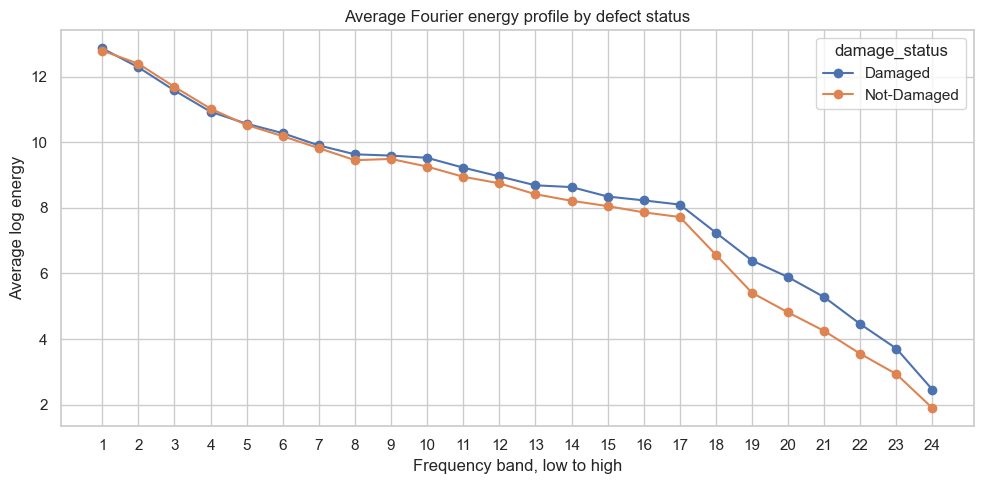

In [8]:
fourier_frame = pd.DataFrame(X_fourier, columns=fourier_feature_names)
fourier_frame["damage_status"] = labels

frequency_columns = [name for name in fourier_feature_names if name.startswith("freq_")]
profile = fourier_frame.groupby("damage_status")[frequency_columns].mean().T

ax = profile.plot(figsize=(10, 5), marker="o", title="Average Fourier energy profile by defect status")
ax.set_xlabel("Frequency band, low to high")
ax.set_ylabel("Average log energy")
ax.set_xticks(range(len(frequency_columns)))
ax.set_xticklabels(range(1, len(frequency_columns) + 1), rotation=0)
plt.tight_layout()
plt.show()

## 9. Train/test split

In [9]:
stratify_labels = safe_stratify_labels(labels)
X_train, X_test, y_train, y_test, train_images, test_images, train_records, test_records = train_test_split(
    X_fourier,
    labels,
    images_scaled,
    filtered_records,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_labels,
)

print("Train set size:", len(X_train))
print("Test set size:", len(X_test))
print("Used stratified split:", stratify_labels is not None)

Train set size: 56
Test set size: 24
Used stratified split: True


## 10. Evaluation helpers

In [10]:
model_summaries = []


def show_prediction_gallery(images, truths, preds, indices, title, max_images=6):
    selected = list(indices)[:max_images]
    if not selected:
        display(Markdown(f"**{title}:** none available in this split."))
        return

    columns = min(3, len(selected))
    rows = math.ceil(len(selected) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax in axes:
        ax.axis("off")

    for ax, idx in zip(axes, selected):
        ax.imshow(images[idx], cmap="gray")
        ax.set_title(f"True: {truths[idx]}\nPred: {preds[idx]}", fontsize=10)
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def evaluate_predictions(model_name, truths, preds, images, train_seconds=0.0, cmap="Blues"):
    accuracy = accuracy_score(truths, preds)
    model_summaries.append({"model": model_name, "accuracy": accuracy, "train_seconds": train_seconds})

    print(f"{model_name} accuracy: {accuracy:.3f}")
    print(classification_report(truths, preds))

    labels_sorted = sorted(pd.unique(np.array(truths, dtype=object)))
    cm = confusion_matrix(truths, preds, labels=labels_sorted)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=labels_sorted, yticklabels=labels_sorted)
    plt.title(f"{model_name} confusion matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

    correct_indices = [idx for idx, (truth, pred) in enumerate(zip(truths, preds)) if truth == pred]
    incorrect_indices = [idx for idx, (truth, pred) in enumerate(zip(truths, preds)) if truth != pred]
    show_prediction_gallery(images, truths, preds, correct_indices, f"{model_name}: correct examples")
    show_prediction_gallery(images, truths, preds, incorrect_indices, f"{model_name}: incorrect examples")

    return accuracy

## 11. Supervised Fourier defect detector

Supervised Fourier Detector accuracy: 0.792
              precision    recall  f1-score   support

     Damaged       0.73      0.92      0.81        12
 Not-Damaged       0.89      0.67      0.76        12

    accuracy                           0.79        24
   macro avg       0.81      0.79      0.79        24
weighted avg       0.81      0.79      0.79        24



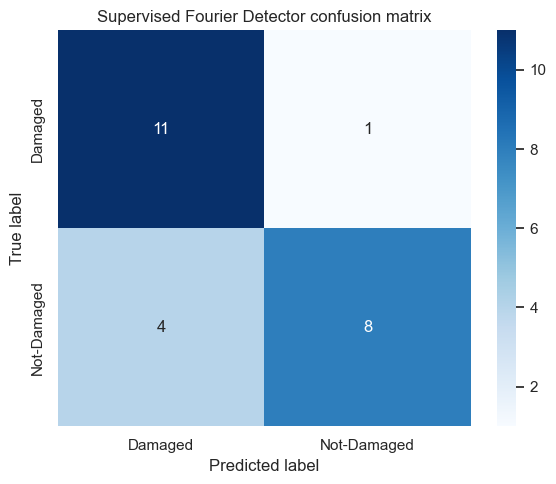

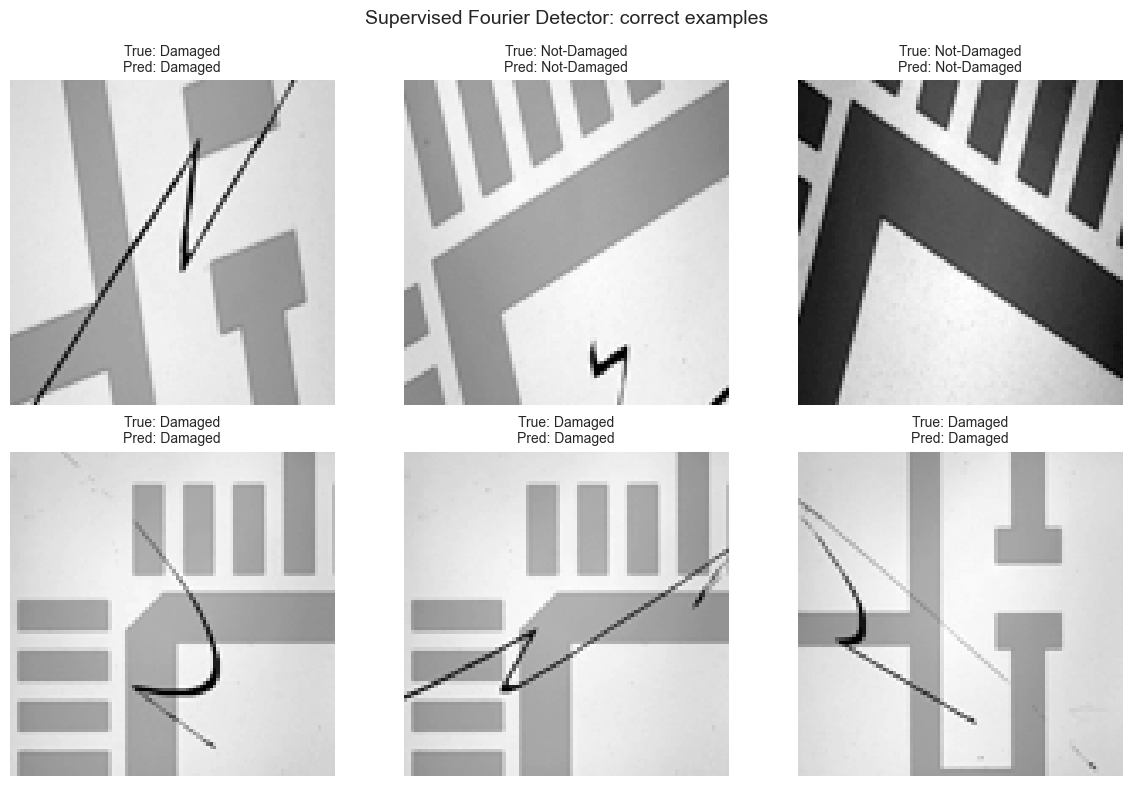

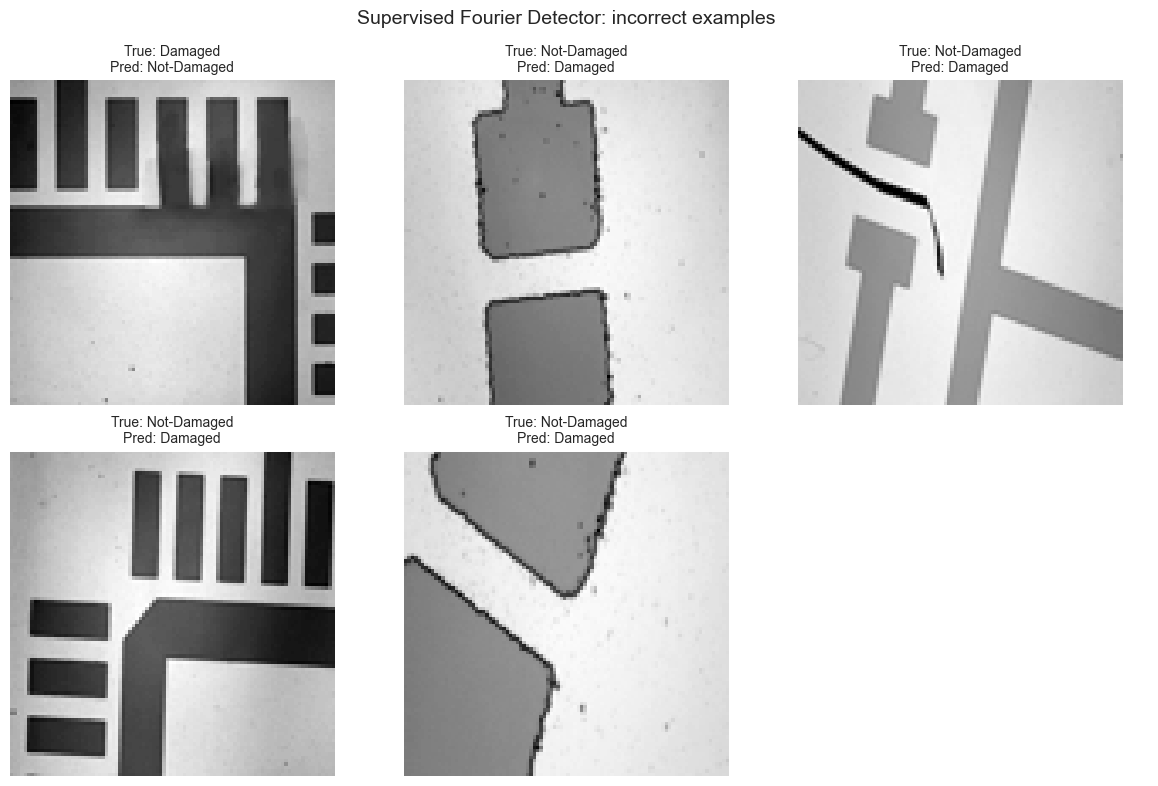

In [11]:
fourier_detector = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000)),
])

started = time.perf_counter()
fourier_detector.fit(X_train, y_train)
train_seconds = record_timing(step_timings, "supervised_fourier_detector", started)
supervised_preds = fourier_detector.predict(X_test)

supervised_accuracy = evaluate_predictions(
    "Supervised Fourier Detector",
    y_test,
    supervised_preds,
    test_images,
    train_seconds=train_seconds,
    cmap="Blues",
)

## 12. Clean-reference Fourier anomaly detector

This version learns only what normal images look like in Fourier-feature space. Then it flags test images whose frequency summaries are far from the clean training profile.

Clean-reference threshold: 1.298
Clean-Reference Fourier Detector accuracy: 0.750
              precision    recall  f1-score   support

     Damaged       0.88      0.58      0.70        12
 Not-Damaged       0.69      0.92      0.79        12

    accuracy                           0.75        24
   macro avg       0.78      0.75      0.74        24
weighted avg       0.78      0.75      0.74        24



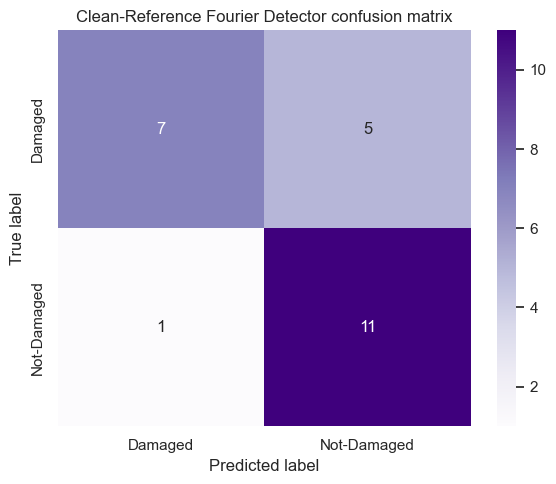

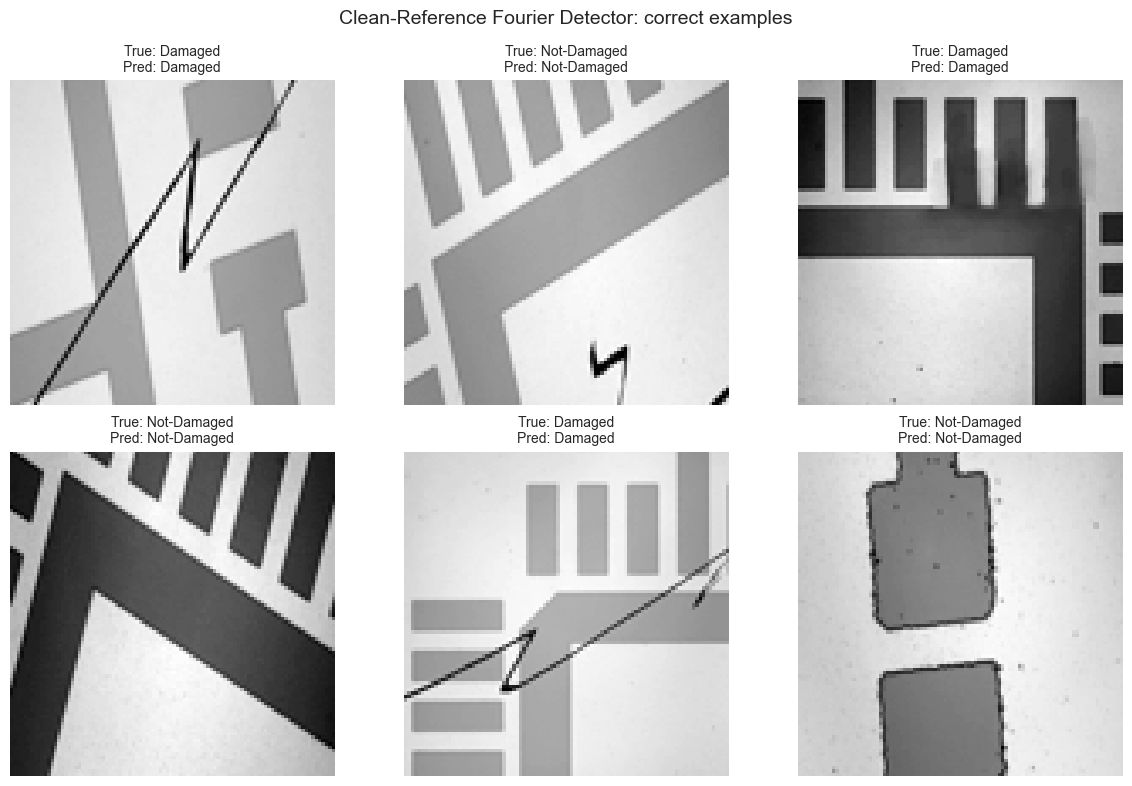

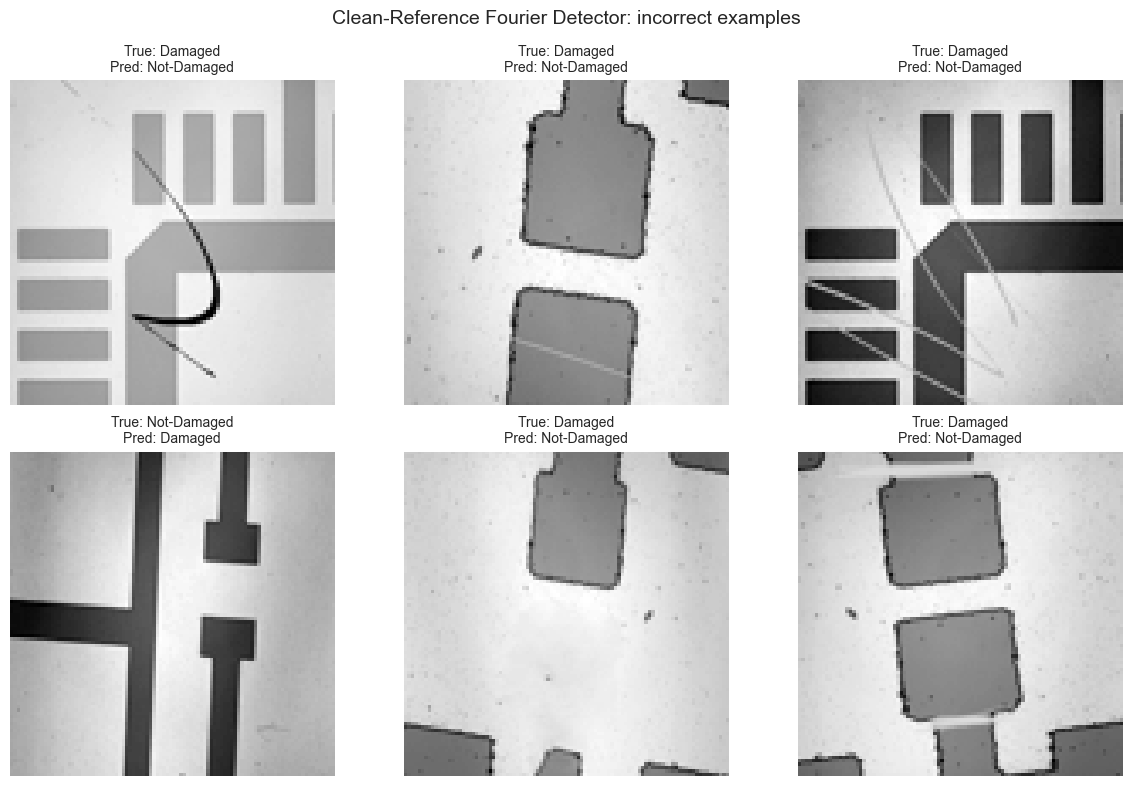

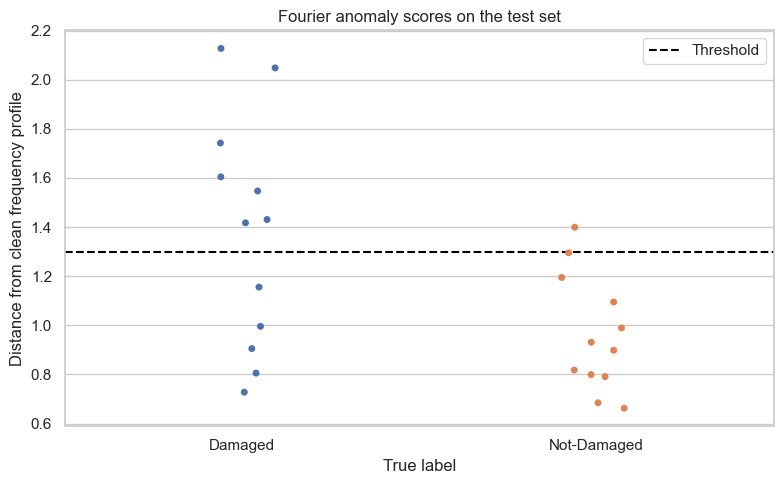

In [12]:
def fit_clean_frequency_reference(X_values, y_values, normal_label=NORMAL_LABEL):
    clean_X = X_values[np.asarray(y_values) == normal_label]
    if len(clean_X) < 2:
        raise ValueError("The clean-reference detector needs at least two normal training images.")
    mean = clean_X.mean(axis=0)
    std = clean_X.std(axis=0) + 1e-6
    clean_scores = np.sqrt(np.mean(((clean_X - mean) / std) ** 2, axis=1))
    threshold = np.percentile(clean_scores, ANOMALY_THRESHOLD_PERCENTILE)
    return mean, std, threshold, clean_scores


def score_frequency_anomaly(X_values, mean, std):
    return np.sqrt(np.mean(((X_values - mean) / std) ** 2, axis=1))


started = time.perf_counter()
clean_mean, clean_std, anomaly_threshold, clean_train_scores = fit_clean_frequency_reference(X_train, y_train)
train_seconds = record_timing(step_timings, "clean_reference_fourier_detector", started)

test_scores = score_frequency_anomaly(X_test, clean_mean, clean_std)
anomaly_preds = np.where(test_scores > anomaly_threshold, DEFECT_LABEL, NORMAL_LABEL)

print(f"Clean-reference threshold: {anomaly_threshold:.3f}")
anomaly_accuracy = evaluate_predictions(
    "Clean-Reference Fourier Detector",
    y_test,
    anomaly_preds,
    test_images,
    train_seconds=train_seconds,
    cmap="Purples",
)

score_frame = pd.DataFrame({"true_label": y_test, "anomaly_score": test_scores})
plt.figure(figsize=(8, 5))
sns.stripplot(data=score_frame, x="true_label", y="anomaly_score", hue="true_label", dodge=False, legend=False)
plt.axhline(anomaly_threshold, color="black", linestyle="--", label="Threshold")
plt.title("Fourier anomaly scores on the test set")
plt.xlabel("True label")
plt.ylabel("Distance from clean frequency profile")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Which frequency bands mattered?

,feature,importance
12,freq_0.50_0.54,1.397996
20,freq_0.83_0.88,0.911332
13,freq_0.54_0.58,0.784215
15,freq_0.62_0.67,0.723652
14,freq_0.58_0.62,0.657333
11,freq_0.46_0.50,0.628297
6,freq_0.25_0.29,0.595199
5,freq_0.21_0.25,0.569487
21,freq_0.88_0.92,0.567251
10,freq_0.42_0.46,0.556820


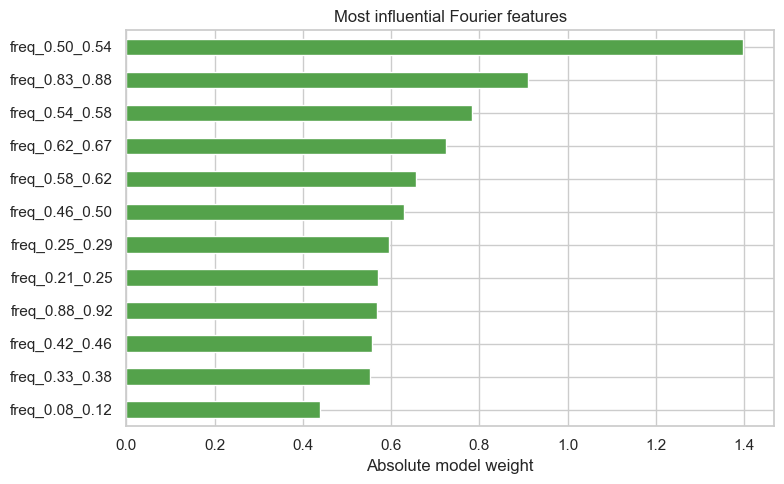

In [13]:
classifier = fourier_detector.named_steps["clf"]
coef = np.abs(classifier.coef_).reshape(-1)
importance_frame = pd.DataFrame({
    "feature": fourier_feature_names,
    "importance": coef,
}).sort_values("importance", ascending=False)

display(importance_frame.head(10))

ax = importance_frame.head(12).sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False,
    color="#54a24b",
    title="Most influential Fourier features",
)
ax.set_xlabel("Absolute model weight")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 14. Patch-level Fourier heatmap

The previous sections make one prediction for the whole image. This section splits each image into patches and compares each patch's high-frequency energy with clean patches at the same position.

This is not a perfect localization algorithm, but it gives students a visual way to ask: **where does this image have unusual texture or edge energy?**

In [14]:
def patch_high_frequency_ratio(patch, high_frequency_start=PATCH_HIGH_FREQUENCY_START):
    centered = patch.astype(float) - patch.mean()
    spectrum = np.fft.fftshift(np.fft.fft2(centered))
    power = np.abs(spectrum) ** 2
    total_power = power.sum() + 1e-12

    y, x = np.indices(patch.shape)
    center = (patch.shape[0] - 1) / 2
    radius = np.sqrt((x - center) ** 2 + (y - center) ** 2)
    radius = radius / radius.max()
    high_mask = radius >= high_frequency_start
    return power[high_mask].sum() / total_power


def patch_frequency_grid(image, patch_size=PATCH_SIZE):
    usable_height = (image.shape[0] // patch_size) * patch_size
    usable_width = (image.shape[1] // patch_size) * patch_size
    cropped = image[:usable_height, :usable_width]
    rows = usable_height // patch_size
    cols = usable_width // patch_size
    grid = np.zeros((rows, cols), dtype=float)

    for row in range(rows):
        for col in range(cols):
            patch = cropped[
                row * patch_size : (row + 1) * patch_size,
                col * patch_size : (col + 1) * patch_size,
            ]
            grid[row, col] = patch_high_frequency_ratio(patch)
    return grid


def fit_clean_patch_reference(images, labels, normal_label=NORMAL_LABEL):
    clean_images = images[np.asarray(labels) == normal_label]
    if len(clean_images) < 2:
        raise ValueError("Patch reference needs at least two normal images.")
    clean_grids = np.stack([patch_frequency_grid(image) for image in clean_images], axis=0)
    return clean_grids.mean(axis=0), clean_grids.std(axis=0) + 1e-6


def patch_anomaly_heatmap(image, clean_patch_mean, clean_patch_std):
    grid = patch_frequency_grid(image)
    zscore = (grid - clean_patch_mean) / clean_patch_std
    zscore = np.clip(zscore, 0, HEATMAP_ZSCORE_CLIP)
    return zscore


clean_patch_mean, clean_patch_std = fit_clean_patch_reference(train_images, y_train)
print("Patch reference grid shape:", clean_patch_mean.shape)

Patch reference grid shape: (6, 6)


## 15. Show Fourier heatmaps on test images

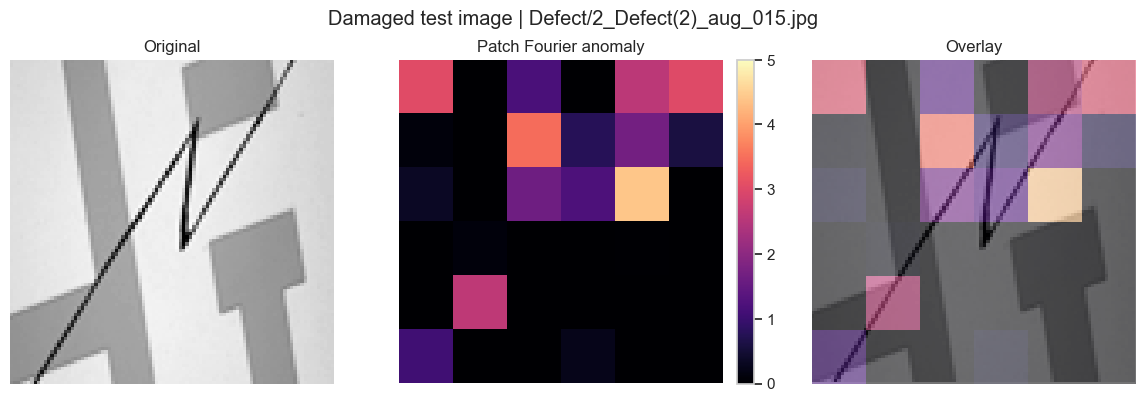

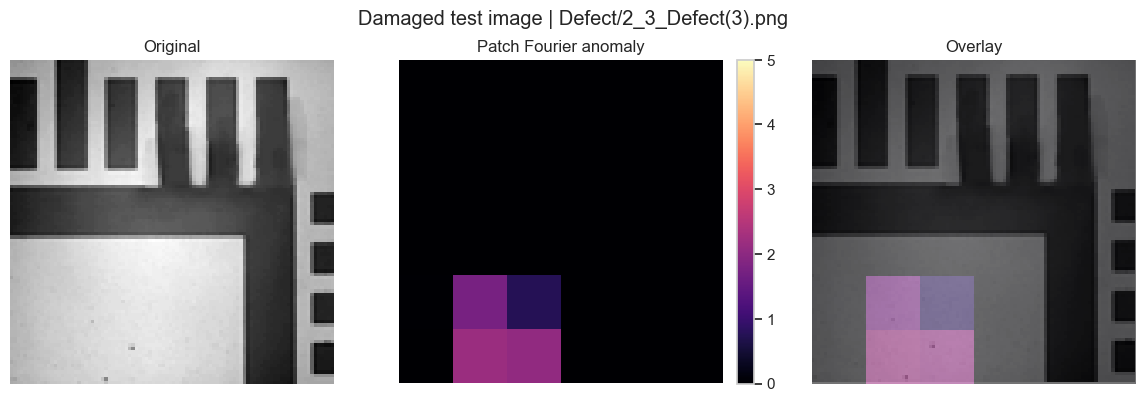

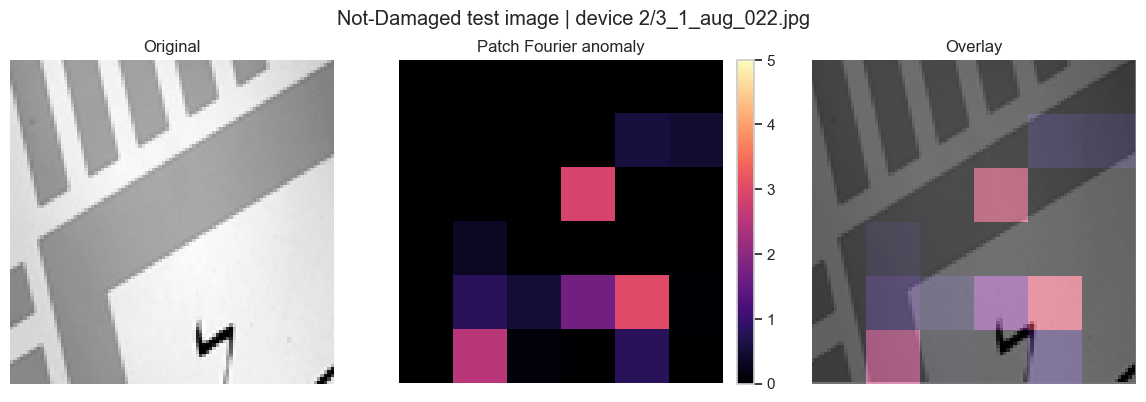

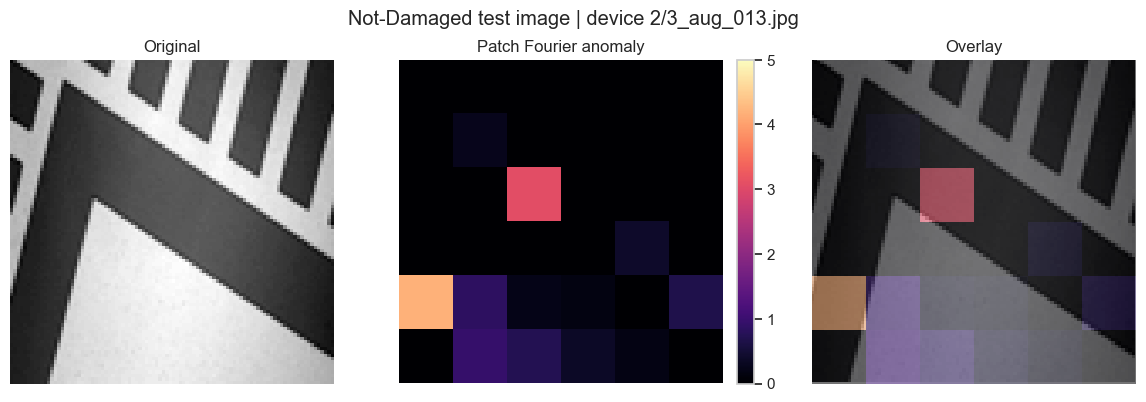

In [15]:
def show_patch_heatmap(image, heatmap, title):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    im = axes[1].imshow(heatmap, cmap="magma", vmin=0, vmax=HEATMAP_ZSCORE_CLIP)
    axes[1].set_title("Patch Fourier anomaly")
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(image, cmap="gray")
    axes[2].imshow(heatmap, cmap="magma", alpha=0.55, extent=(0, image.shape[1], image.shape[0], 0), vmin=0, vmax=HEATMAP_ZSCORE_CLIP)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


shown = 0
for desired_label in [DEFECT_LABEL, NORMAL_LABEL]:
    label_indices = np.where(y_test == desired_label)[0]
    for idx in label_indices[:2]:
        heatmap = patch_anomaly_heatmap(test_images[idx], clean_patch_mean, clean_patch_std)
        rel_path = test_records.iloc[idx]["relative_path"]
        show_patch_heatmap(test_images[idx], heatmap, f"{desired_label} test image | {rel_path}")
        shown += 1

if shown == 0:
    display(Markdown("**No test images available for heatmap display.**"))

## 16. Final comparison summary

,step,seconds
0,dataset_scan,0.010
1,load_grayscale_images,0.923
2,fourier_feature_extraction,0.032
3,supervised_fourier_detector,0.006
4,clean_reference_fourier_detector,0.002


,model,accuracy,train_seconds
0,Supervised Fourier Detector,0.791667,0.006109
1,Clean-Reference Fourier Detector,0.750000,0.001529


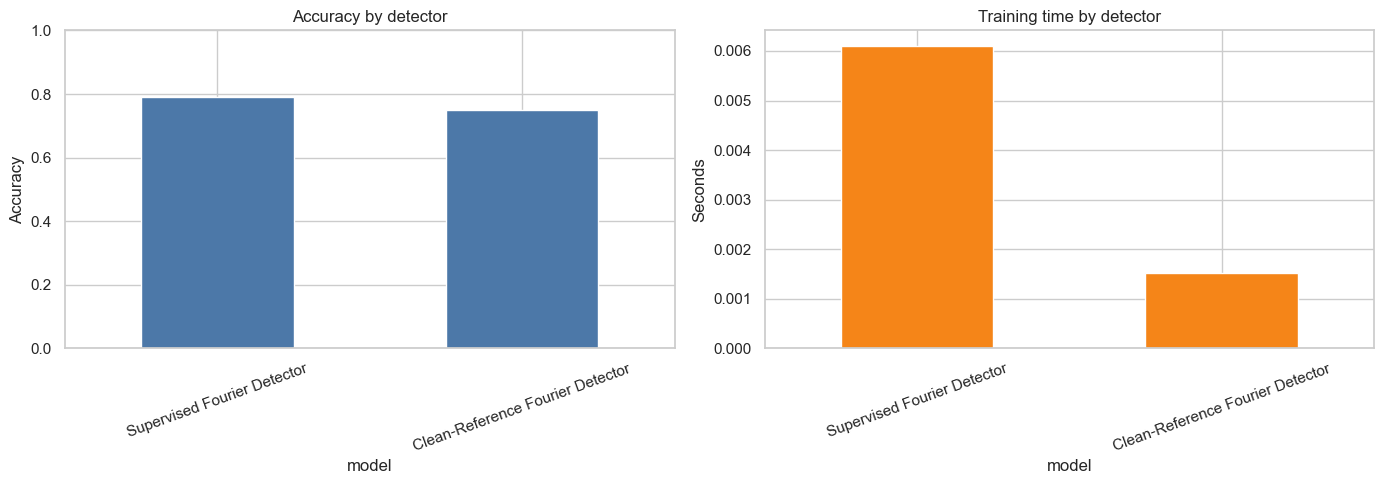

**Reflection prompts:** Did the supervised detector or clean-reference detector work better? Which frequency bands mattered most? Did the heatmap point to believable suspicious regions? What defects might Fourier features miss if the damage changes location more than texture?

In [16]:
runtime_table = timing_frame(step_timings)
display(runtime_table)

comparison_table = pd.DataFrame(model_summaries)
comparison_table = comparison_table.sort_values(by="accuracy", ascending=False).reset_index(drop=True)
display(comparison_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparison_table.plot(kind="bar", x="model", y="accuracy", color="#4c78a8", legend=False, ax=axes[0], title="Accuracy by detector")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

comparison_table.plot(kind="bar", x="model", y="train_seconds", color="#f58518", legend=False, ax=axes[1], title="Training time by detector")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(Markdown(
    "**Reflection prompts:** Did the supervised detector or clean-reference detector work better? "
    "Which frequency bands mattered most? Did the heatmap point to believable suspicious regions? "
    "What defects might Fourier features miss if the damage changes location more than texture?"
))

## 17. What students should notice

Fourier defect detection looks for changes in frequency behavior.

- It can respond strongly to scratches, roughness, sharp edges, blur, or repeated texture changes.
- A supervised detector uses both damaged and not-damaged examples.
- A clean-reference detector only learns normal behavior, which is closer to real inspection settings where new defect types may appear later.
- Patch heatmaps can suggest suspicious regions, but they are not ground-truth segmentation masks.
- Lighting, focus, and augmentation artifacts can also change frequencies, so a high score is evidence to inspect, not proof by itself.

Good experiments to try next:
- Change `PATCH_HIGH_FREQUENCY_START`.
- Change `PATCH_SIZE`.
- Train on one device type by setting `INCLUDED_DEVICE_TYPES`.
- Compare the Fourier heatmap with the clustering notebook's suspicious regions.